# Convergencia

## Analisis

En este libro probaremos y graficaremos la convergencia de los modelos para ver como se van comportando. De esta forma veremos como se comporta con diferentes dataSet y con ayuda de este entorno grafico podremos entender mejor que está sucediendo.

In [19]:
#Primero de todo importamos las librerías necesarias para el proyecto

#Librerias para la creacion de los modelos
import tensorflow as tf
from tensorflow import keras
import sklearn
from keras import layers
from sklearn.preprocessing import MinMaxScaler

#Librerias para la carga de los datos
from ucimlrepo import fetch_ucirepo 

#Libreria para dibujar graficos
import matplotlib.pyplot as plt


In [20]:
#Ahora importamos nuestra capa creada que vamos a analizar en este proyecto siendo la que tiene el polinomio de Lagrange

class PolynomialDense2(tf.keras.layers.Layer):
    def __init__(self, units, degree=2, use_bias=True, **kwargs):
        super(PolynomialDense2, self).__init__(**kwargs)
        self.units = units
        self.degree = degree
        self.use_bias = use_bias

    def build(self, input_shape):
        input_dim = input_shape[-1]
        # El kernel debe cubrir (grado + 1) si incluyes P0, o (grado) si empiezas en P1
        # Aquí usaremos desde P1 hasta P_degree
        self.kernel = self.add_weight(
            shape=(input_dim * self.degree, self.units),
            initializer=tf.keras.initializers.GlorotUniform(),
            trainable=True,
            name="kernel"
        )

        if self.use_bias:
            self.bias = self.add_weight(
                shape=(self.units,),
                initializer="zeros",
                trainable=True,
                name="bias"
            )

    def call(self, inputs):
        # Aseguramos que los inputs sean float32
        x = tf.cast(inputs, self.compute_dtype)
        
        # P0 = 1, P1 = x
        p_nm2 = tf.ones_like(x)
        p_nm1 = x
        
        features = [p_nm1] # Empezamos con grado 1

        for n in range(2, self.degree + 1):
            n_float = tf.cast(n, self.compute_dtype)
            # Fórmula de recurrencia de Legendre
            p_n = ((2.0 * n_float - 1.0) * x * p_nm1 - (n_float - 1.0) * p_nm2) / n_float
            features.append(p_n)
            
            p_nm2 = p_nm1
            p_nm1 = p_n

        # Concatenamos: (batch, input_dim * degree)
        # Esto genera: [x_poly1, x_poly2, ..., x_poly_degree]
        phi = tf.concat(features, axis=-1)

        output = tf.matmul(phi, self.kernel)

        if self.use_bias:
            output = tf.nn.bias_add(output, self.bias)

        return output

In [21]:
#Ahora debemos debemos de crear una función para dibujar la grafica de entrenamiento
def plot_training_history(history):
    plt.figure(figsize=(12, 5))
    
    # Pérdida
    plt.subplot(1, 2, 1)
    plt.plot(history.history['loss'], label='Pérdida de entrenamiento')
    plt.plot(history.history['val_loss'], label='Pérdida de validación')
    plt.title('Pérdida durante el entrenamiento')
    plt.xlabel('Épocas')
    plt.ylabel('Pérdida')
    plt.legend()
    
    # Precisión
    plt.subplot(1, 2, 2)
    plt.plot(history.history['accuracy'], label='Precisión de entrenamiento')
    plt.plot(history.history['val_accuracy'], label='Precisión de validación')
    plt.title('Precisión durante el entrenamiento')
    plt.xlabel('Épocas')
    plt.ylabel('Precisión')
    plt.legend()
    
    plt.tight_layout()
    plt.show()

In [22]:
#Cargamos los datos del Dataset.
# fetch dataset 
magic_gamma_telescope = fetch_ucirepo(id=159) 
  
X = magic_gamma_telescope.data.features 
y = magic_gamma_telescope.data.targets 

#Separamos el dataset en entrenamiento y test
from sklearn.model_selection import train_test_split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

#Normalizamos los datos para que el entrenamiento sea más eficiente entre -1 y 1
scaler = MinMaxScaler(feature_range=(-1, 1))
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

#Cambiamos las etiquetas a 0 y 1
y_train = (y_train == 'g').astype(int)
y_test = (y_test == 'g').astype(int)

In [24]:
#Ahora crearemos un modelo y lo entrenaremos.

input_dim = X_train.shape[1]

#Modelo polinómico grado 2


inputPoli = keras.Input(shape=(input_dim,))
x = PolynomialDense2(32, degree=2)(inputPoli)
x = layers.Activation('swish')(x)
x = layers.Dense(16, activation='swish')(x)
outputPoli = layers.Dense(3, activation='softmax')(x)

#Modelo polinómico grado 3
inputPoli3 = keras.Input(shape=(input_dim,))
x3 = PolynomialDense2(32, degree=3)(inputPoli3)
x3 = layers.Activation('swish')(x3)
x3 = layers.Dense(16, activation='swish')(x3)
outputPoli3 = layers.Dense(3, activation='softmax')(x3)

#Modelo polinómico grado 4
inputPoli4 = keras.Input(shape=(input_dim,))
x4 = PolynomialDense2(32, degree=4)(inputPoli4)
x4 = layers.Activation('swish')(x4)
x4 = layers.Dense(16, activation='swish')(x4)
outputPoli4 = layers.Dense(3, activation='softmax')(x4)

In [25]:
#Creamos los modelos
model_poli2 = keras.Model(inputs=inputPoli, outputs=outputPoli, name="Polynomial_Model_Degree_2")
model_poli3 = keras.Model(inputs=inputPoli3, outputs=outputPoli3, name="Polynomial_Model_Degree_3")
model_poli4 = keras.Model(inputs=inputPoli4, outputs=outputPoli4, name="Polynomial_Model_Degree_4")

#Compilamos los modelos
model_poli2.compile(optimizer='adam', loss='sparse_categorical_crossentropy', metrics=['accuracy'])
model_poli3.compile(optimizer='adam', loss='sparse_categorical_crossentropy', metrics=['accuracy'])
model_poli4.compile(optimizer='adam', loss='sparse_categorical_crossentropy', metrics=['accuracy'])

In [26]:
epochs = 200
batch_size = 32

In [27]:
#Ahora entrenaremos a los modelos y guardaremos el historial para luego dibujar las gráficas de convergencia
history_poli2 = model_poli2.fit(X_train_scaled, y_train, validation_split=0.2, epochs=epochs, batch_size=32)
history_poli3 = model_poli3.fit(X_train_scaled, y_train, validation_split=0.2, epochs=epochs, batch_size=32)
history_poli4 = model_poli4.fit(X_train_scaled, y_train, validation_split=0.2, epochs=epochs, batch_size=32)


Epoch 1/200


381/381 ━━━━━━━━━━━━━━━━━━━━ 2s 2ms/step - accuracy: 0.7610 - loss: 0.5203 - val_accuracy: 0.8219 - val_loss: 0.4182
Epoch 2/200
381/381 ━━━━━━━━━━━━━━━━━━━━ 1s 1ms/step - accuracy: 0.8357 - loss: 0.3945 - val_accuracy: 0.8348 - val_loss: 0.3905
Epoch 3/200
381/381 ━━━━━━━━━━━━━━━━━━━━ 1s 1ms/step - accuracy: 0.8418 - loss: 0.3751 - val_accuracy: 0.8413 - val_loss: 0.3770
Epoch 4/200
381/381 ━━━━━━━━━━━━━━━━━━━━ 1s 1ms/step - accuracy: 0.8466 - loss: 0.3664 - val_accuracy: 0.8426 - val_loss: 0.3697
Epoch 5/200
381/381 ━━━━━━━━━━━━━━━━━━━━ 1s 1ms/step - accuracy: 0.8490 - loss: 0.3628 - val_accuracy: 0.8459 - val_loss: 0.3661
Epoch 6/200
381/381 ━━━━━━━━━━━━━━━━━━━━ 1s 1ms/step - accuracy: 0.8501 - loss: 0.3572 - val_accuracy: 0.8495 - val_loss: 0.3627
Epoch 7/200
381/381 ━━━━━━━━━━━━━━━━━━━━ 1s 1ms/step - accuracy: 0.8534 - loss: 0.3550 - val_accuracy: 0.8472 - val_loss: 0.3649
Epoch 8/200
381/381 ━━━━━━━━━━━━━━━━━━━━ 1s 1ms/step - accuracy: 0.8570 - loss: 0.3518 - val_accuracy: 0.8515

Gráfica de convergencia para el modelo polinómico de grado 2 con accuracy: 0.88197


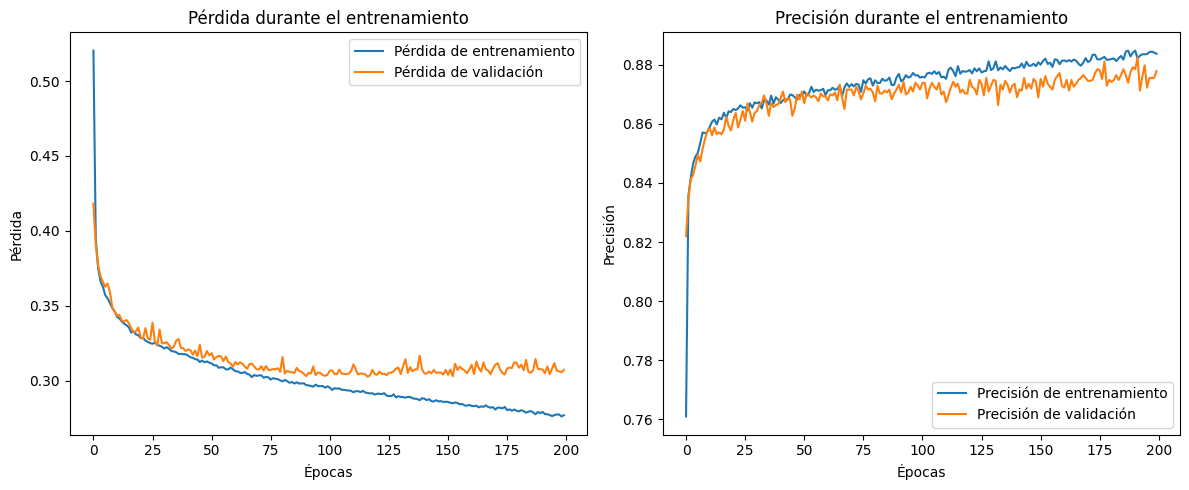

Gráfica de convergencia para el modelo polinómico de grado 3 con accuracy: 0.88249


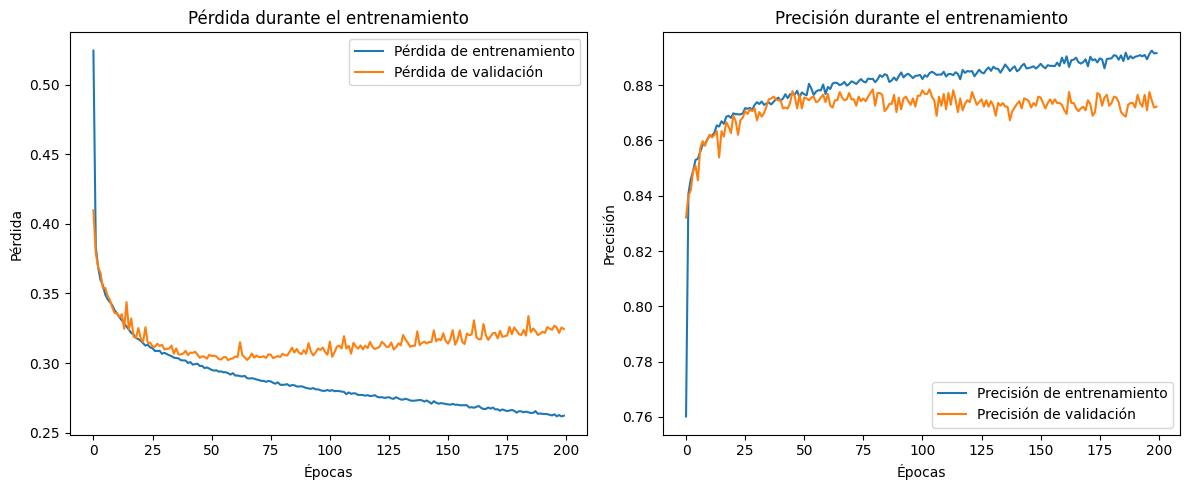

Gráfica de convergencia para el modelo polinómico de grado 4 con accuracy: 0.87645


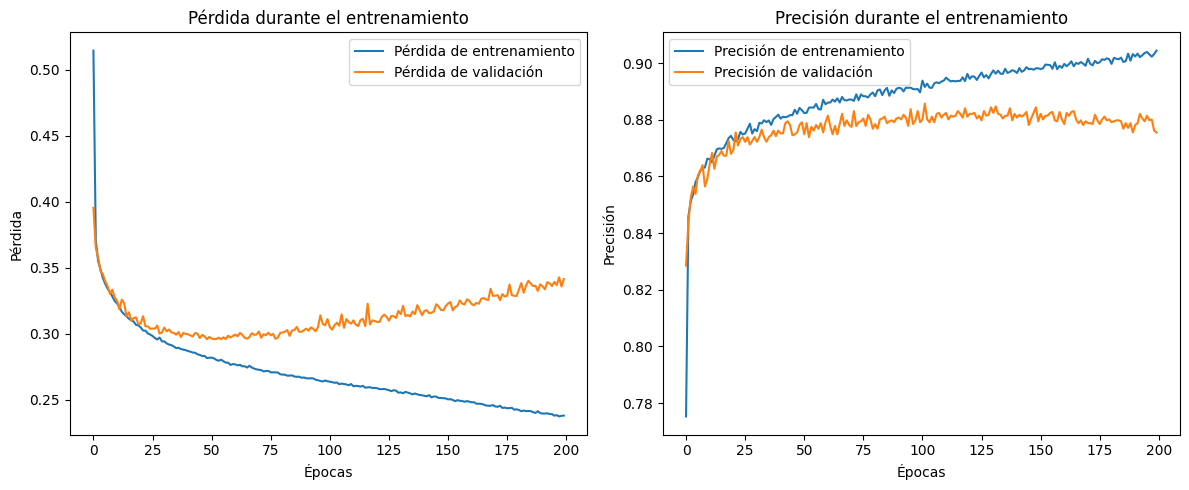

In [28]:
#Dibujamos las gráficas de convergencia para cada modelo u debajo el acurracy obtenido en el test
print("Gráfica de convergencia para el modelo polinómico de grado 2 con accuracy: {:.5f}".format(model_poli2.evaluate(X_test_scaled, y_test, verbose=0)[1]))
plot_training_history(history_poli2)
print("Gráfica de convergencia para el modelo polinómico de grado 3 con accuracy: {:.5f}".format(model_poli3.evaluate(X_test_scaled, y_test, verbose=0)[1]))
plot_training_history(history_poli3)
print("Gráfica de convergencia para el modelo polinómico de grado 4 con accuracy: {:.5f}".format(model_poli4.evaluate(X_test_scaled, y_test, verbose=0)[1]))
plot_training_history(history_poli4)
